# Comparing all conditions - with generation feedback and without it - Does our generation feedback improve descriptions?
### description lengths - "token_num"
### validated objects - all objects + hallucinations by each subject - per attempt and per condition
###  gen images similarity - are gen images when aiming for that look more similar to the original image than ones based on descriptions that were not meant for it (without our feedback)
### exploratory analyses - how many erasings, how many additions of words per attempt...



In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [2]:
# df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/feedback_vs_no_feedback.csv")
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/all_feedback_no_feedback.csv")
save_path = "/mnt/hdd/anatkorol/Imagination_in_translation/analysis/comparing_conditions"
#with feedback:
perception_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
memory_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
delay_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
# no feedback:

perception_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/29032026_pilot_2_perception_no_feedback/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
memory_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/07052026_pilot_2_immediate_memory_no_feedback/nlp_analysis/ppt_trials_w_object_validation.csv").copy()
delay_no_feedback = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/07052026_pilot_2_delayed_memory_digit_span_no_feedback/nlp_analysis/ppt_trials_w_object_validation.csv").copy()

#new condition - analysis on it's own
no_attempts = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/240526_pilot_2_immediate_memory_no_feedback_no_attempts/ppt_trials_w_similarity_trials.csv")
#deleting gpt-5 rows from all dfs
perception_feedback = perception_feedback[perception_feedback['uid'] != "gpt-5"]
memory_feedback = memory_feedback[memory_feedback['uid'] != "gpt-5"]
delay_feedback = delay_feedback[delay_feedback['uid'] != "gpt-5"]

In [ ]:
# #adding condition and feedback columns
# perception_feedback["condition"] = "perception"
# perception_feedback["feedback"] = "feedback"

# memory_feedback["condition"] = "immediate memory"
# memory_feedback["feedback"] = "feedback"

# delay_feedback["condition"] = "delayed memory"
# delay_feedback["feedback"] = "feedback"

# perception_no_feedback["condition"] = "perception"
# perception_no_feedback["feedback"] = "no-feedback"

# memory_no_feedback["condition"] = "immediate memory"
# memory_no_feedback["feedback"] = "no-feedback"

# delay_no_feedback["condition"] = "delayed memory"
# delay_no_feedback["feedback"] = "no-feedback"


# df = pd.concat([perception_feedback, memory_feedback, delay_feedback, perception_no_feedback, memory_no_feedback, delay_no_feedback], ignore_index=True)
# #df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/all_feedback_no_feedback.csv", index=False)

In [34]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'item_evaluations',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects', 'error', 'condition',
       'feedback', 'clip_cosine_distance', 'vgg_fc7_distance',
       'clip_vis_text_similarity', 'token_num_x', 'token_num_y', 'token_num'],
      dtype='object')

In [35]:
# turning the category details into actual lists instead of strings
import ast
list_cols = ['objects', 'attr_color', 'spatial_relations', 'subjective_detail'] 

# turning the python strings into real lists
def to_list(x):
    # Already a list
    if isinstance(x, list):
        return x
    # Missing values
    if pd.isna(x):
        return []
    # String that looks like a list
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "null":
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                v = ast.literal_eval(s)
                return v if isinstance(v, list) else []
            except Exception:
                return []
    # Anything else
    return []

def converted (df):
    # Convert columns to real lists
    for c in list_cols:
        if c in df.columns:
            df[c] = df[c].apply(to_list)
    return df


#apply conversion to each df
df = converted(df)



# comparing by prompt length

In [36]:
df['prompt_word_count'] = df['prompt'].fillna('').str.split().str.len()
df['prompt_char_count'] = df['prompt'].fillna('').str.len()

In [30]:
df.columns

Index(['uid', 'gt', 'session', 'attempt', 'prompt', 'gen', 'subjective_score',
       'prompt_latency_secs', 'generating_latency_secs', 'rating_latency_secs',
       'ts', 'study_result', 'comp_result', 'verbosity', 'extraction',
       'objects', 'attr_color', 'attr_shape', 'attr_size', 'attr_material',
       'attr_texture', 'attr_pose', 'attr_action', 'attr_state',
       'spatial_relations', 'world_knowledge', 'scene', 'camera_aspects',
       'optical_effects', 'subjective_detail', 'item_evaluations',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects', 'error', 'condition',
       'feedback', 'clip_cosine_distance', 'vgg_fc7_distance',
       'clip_vis_text_similarity', 'token_num', 'prompt_word_count',
       'prompt_char_count', 'feedback_label'],
      dtype='object')

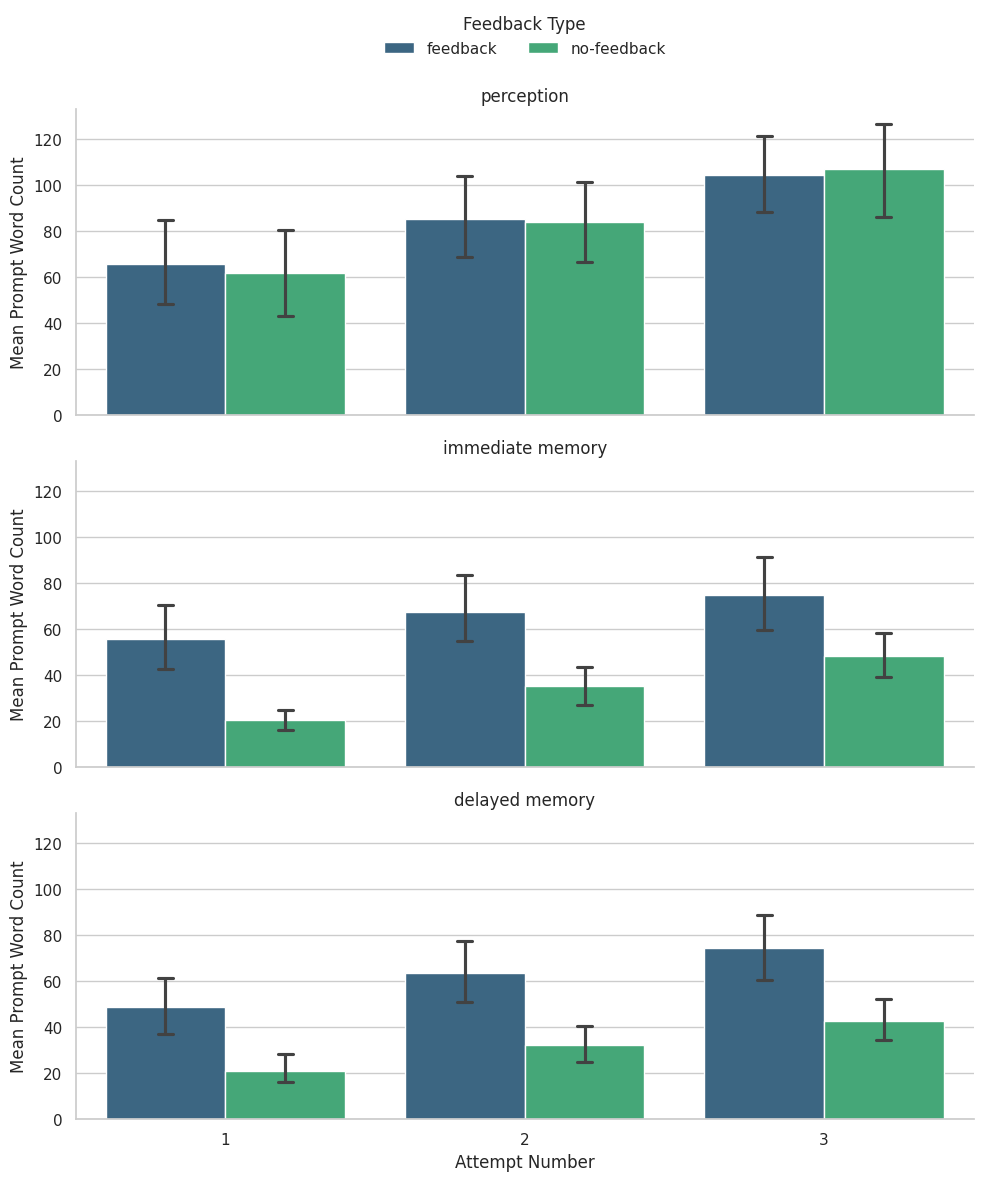

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the grid
g = sns.FacetGrid(
    df, 
    row="condition", 
    row_order=['perception', 'immediate memory', 'delayed memory'],
    height=4, 
    aspect=2.5, 
    sharex=True
)

# Map the barplot (ensure legend=False so we can customize its position)
g.map_dataframe(
    sns.barplot, 
    x="attempt", 
    y="prompt_word_count", 
    hue="feedback", 
    palette="viridis",
    capsize=.1
)

# Remove the automatic legend and titles to clear space
g.set_titles(row_template="{row_name}")
g.set_axis_labels("Attempt Number", "Mean Prompt Word Count")

# Place the legend at the top
# bbox_to_anchor coordinates: (x, y, width, height)
plt.legend(
    title="Feedback Type", 
    bbox_to_anchor=(0.5, 3.65), # Adjust the 3.65 based on final plot scaling
    loc='upper center', 
    ncol=2, 
    frameon=False
)

# Adjust subplots to make room for the legend at the top
plt.subplots_adjust(top=0.9)
plt.show()

## comparing them based on token_num (length of description)

# let's compare counts - objects, spatial relations and color attributes

In [33]:
selected_columns = ["objects", "spatial_relations", "attr_color", "attr_size", "attr_texture", "camera_aspects"]

In [39]:
# converting wide to long and adding a count column for the number of items in each category
# required id columns (adjust if your names differ)
id_cols = ["condition", "attempt", "uid", "gt"]

long = df.melt(
    id_vars=id_cols,
    value_vars=selected_columns,
    var_name="category",
    value_name="items"
)

def safe_len(x):
    """Length for list-like; 0 for NaN/None; 1 for scalar non-list values."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return 0
    if isinstance(x, (list, tuple, set, dict)):
        return len(x)
    return 1

long["count"] = long["items"].apply(safe_len)

# Keep category order as selected_columns
long["category"] = pd.Categorical(long["category"], categories=selected_columns, ordered=True)

In [46]:
#great aggregation but no variance per participant
# # Assuming your dataframe is named 'df'
# # Aggregating across participants (uid) and images (gt) - they are averaged out in the process, so we get a single mean count per category/condition/attempt
condition_order = ['feedback', 'no_feedback']
long['condition'] = pd.Categorical(long['condition'], categories=condition_order, ordered=True)

agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()

# Sort for consistent plotting (Attempt 1, 2, 3)
agg_df = agg_df.sort_values(by=['category', 'condition', 'attempt'])


/tmp/ipykernel_294642/4021671284.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = long.groupby(['category', 'condition', 'attempt'], as_index=False)['count'].mean()


In [47]:
agg_df

,category,condition,attempt,count
0,objects,feedback,1,7.600000
1,objects,feedback,2,8.433333
2,objects,feedback,3,9.033333
3,objects,no_feedback,1,6.466667
4,objects,no_feedback,2,8.166667
5,objects,no_feedback,3,9.733333
6,spatial_relations,feedback,1,3.400000
7,spatial_relations,feedback,2,4.300000
8,spatial_relations,feedback,3,5.333333
9,spatial_relations,no_feedback,1,2.633333


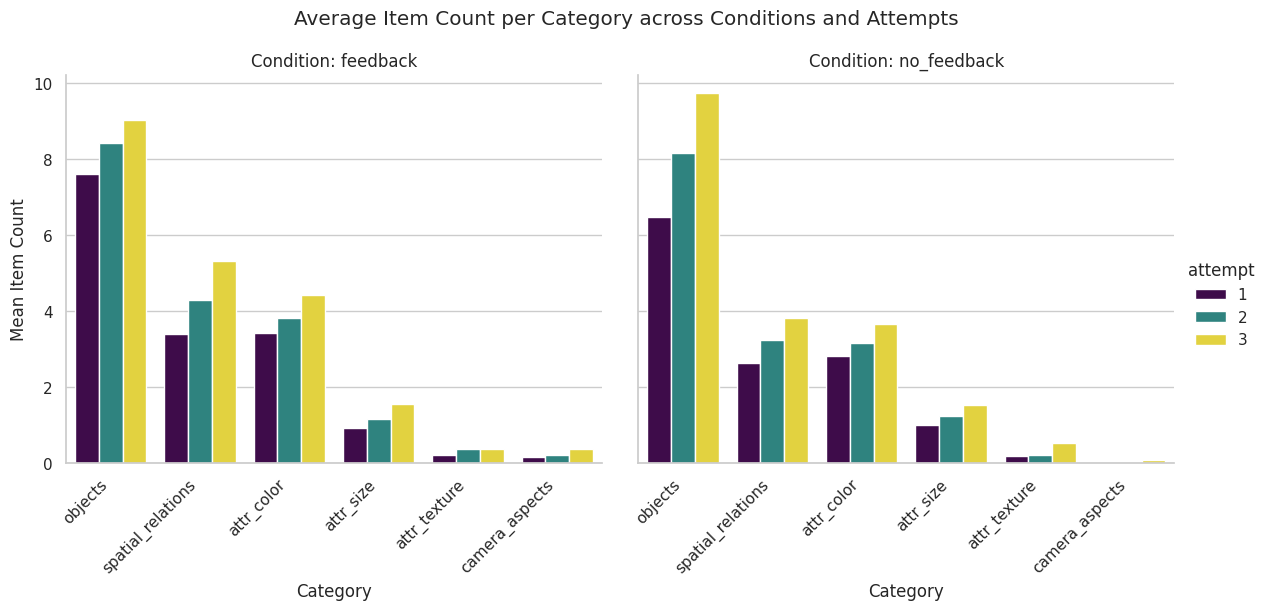

In [48]:
# Setting up the visual style
sns.set_theme(style="whitegrid")

# Creating the faceted bar plot
g = sns.catplot(
    data=agg_df, 
    x='category', 
    y='count', 
    hue='attempt', 
    col='condition', 
    kind='bar',
    palette='viridis',
    height=5, 
    aspect=1.2
)
# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Customizing labels and titles
g.set_axis_labels("Category", "Mean Item Count")
g.set_titles("Condition: {col_name}")
g.fig.suptitle('Average Item Count per Category across Conditions and Attempts', y=1.05)

# plt.savefig('category_analysis_plot.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_294642/3530377025.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_294642/3530377025.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


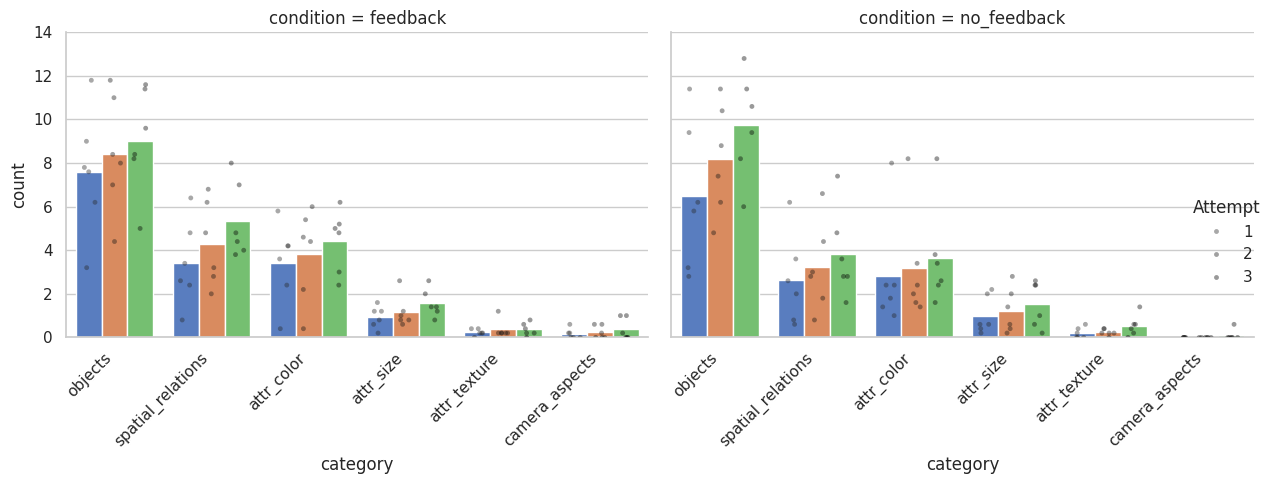

In [54]:
# looking at the individual participants

# Correct Aggregation
# We include 'condition' in the groupby to keep the participant tied to their group.
# We average the 'count' (averaging across the multiple images 'gt' each person saw).
df_participant = long.groupby(
    ['condition', 'uid', 'category', 'attempt'], 
    as_index=False, 
    observed=True  # IMPORTANT: This prevents pandas from creating empty rows for 
                   # combinations that don't exist (like User A in Condition B)
)['count'].mean()

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Choose your colors
bar_palette = "muted"   # "muted", "deep", or "Dark2" are good for darker bars
dot_color = "black"     # Using a single dark color for dots often looks cleaner

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    df_participant, 
    col="condition", 
    col_order=['feedback', 'no_feedback'],
    height=5, 
    aspect=1.2
)

def draw_study_data(data, **kwargs):
    ax = plt.gca()
    
    # DARKER BARS: alpha=1.0 makes them fully opaque
    sns.barplot(
        data=data, x="category", y="count", hue="attempt",
        palette=bar_palette, alpha=1.0, errorbar=None, ax=ax
    )
    
    # CONTRASTING DOTS: Using 'black' or '0.2' (dark gray) 
    # dodge=True keeps them aligned with the specific attempt bar
    sns.stripplot(
        data=data, x="category", y="count", hue="attempt",
        color=dot_color, dodge=True, alpha=0.4, size=3.5, jitter=0.2, ax=ax
    )
    
    if ax.get_legend(): ax.get_legend().remove()

g.map_dataframe(draw_study_data)

# Diagonal Labels
for ax in g.axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

g.add_legend(title="Attempt")
plt.ylim(0, 14)
plt.tight_layout()
# plt.savefig(graphs_path / 'tags_count_seperate_conditions_with_ppt_variablity.png', bbox_inches='tight')
plt.show()